#Import Code

In [ ]:
!pip install datasets
!pip install pandas
!pip install matplotlib
!pip install neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.3/312.3 kB 8.6 MB/s eta 0:00:00


In [ ]:
from collections import Counter
from datasets import load_dataset
from google.colab import files
from neo4j import GraphDatabase

import json
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Downloading Datasets

In [ ]:
euadr = load_dataset("bigbio/euadr", name="euadr_bigbio_kb", split="train")
chemprot_all = load_dataset("bigbio/chemprot", name="chemprot_bigbio_kb")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.02k [00:00<?, ?B/s]

euadr.py:   0%|          | 0.00/14.4k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/537k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/300 [00:00<?, ? examples/s]

...

0000.parquet:   0%|          | 0.00/895k [00:00<?, ?B/s]

Generating sample split:   0%|          | 0/50 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1020 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/612 [00:00<?, ? examples/s]

In [ ]:
train_list = chemprot_all["train"].to_list()
val_list = chemprot_all["validation"].to_list()
test_list = chemprot_all["test"].to_list()

#Import From Files

In [ ]:
with open("/content/euadr_full.json", "r") as f:
    euadr_data = json.load(f)

with open("/content/chemprot_train.json", "r") as f:
    chemprot_train = json.load(f)

with open("/content/chemprot_validation.json", "r") as f:
    chemprot_validation = json.load(f)

with open("/content/chemprot_test.json", "r") as f:
    chemprot_test = json.load(f)

#Dataset Analysis (EU-ADR)

## The Columns in the Dataset

In [ ]:
print("Top-level fields in ChemProt example:")
print(chemprot_train[0].keys())


Top-level fields in ChemProt example:
dict_keys(['id', 'document_id', 'passages', 'entities', 'events', 'coreferences', 'relations'])


##Type of Entities

In [ ]:
# Combine all the datas
all_chemprot = chemprot_train + chemprot_validation + chemprot_test

# Count entity types
entity_counter = Counter()
for sample in all_chemprot:
    for entity in sample.get("entities", []):
        entity_counter[entity["type"]] += 1

entity_counts_df = pd.DataFrame(entity_counter.items(), columns=["Entity Type", "Count"])
entity_counts_df.sort_values(by="Count", ascending=False, inplace=True)

print(entity_counts_df)

  Entity Type  Count
0    CHEMICAL  31831
2      GENE-Y  20157
1      GENE-N  10159


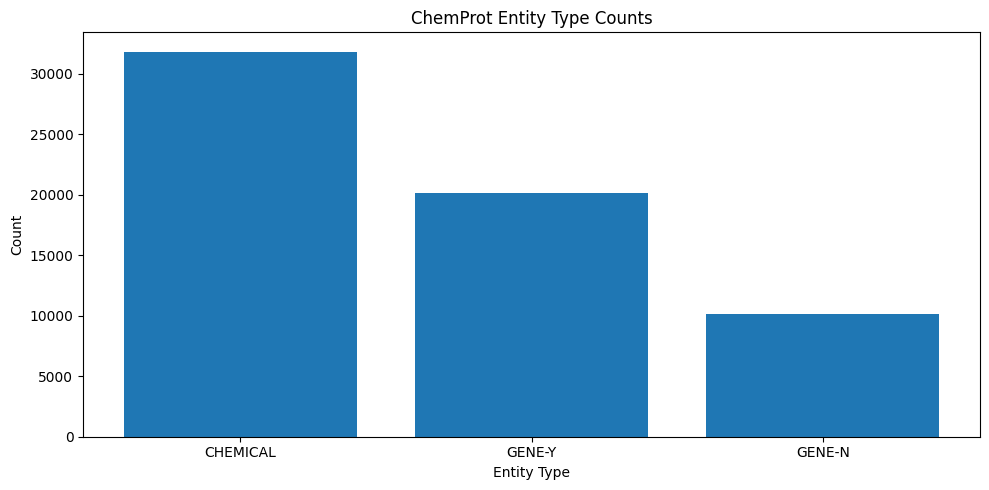

In [ ]:
# Create a bar chart visualization
plt.figure(figsize=(10, 5))
plt.bar(entity_counts_df["Entity Type"], entity_counts_df["Count"])
plt.xlabel("Entity Type")
plt.ylabel("Count")
plt.title("ChemProt Entity Type Counts")
plt.tight_layout()
plt.show()

## Relations in Datasets

In [ ]:
# Count relation types
relation_counter = Counter()
for sample in all_chemprot:
    for relation in sample.get("relations", []):
        relation_counter[relation["type"]] += 1

# Convert to DataFrame
relation_counts_df = pd.DataFrame(relation_counter.items(), columns=["Relation Type", "Count"])
relation_counts_df.sort_values(by="Count", ascending=False, inplace=True)

# Print the table
print(relation_counts_df)


    Relation Type  Count
0   Downregulator   5030
4       Regulator   4175
7     Upregulator   1996
5       Substrate   1828
2      Antagonist    727
6             Not    683
3         Part_of    676
1         Agonist    487
8       Modulator     73
9        Cofactor     61
10      Undefined      3


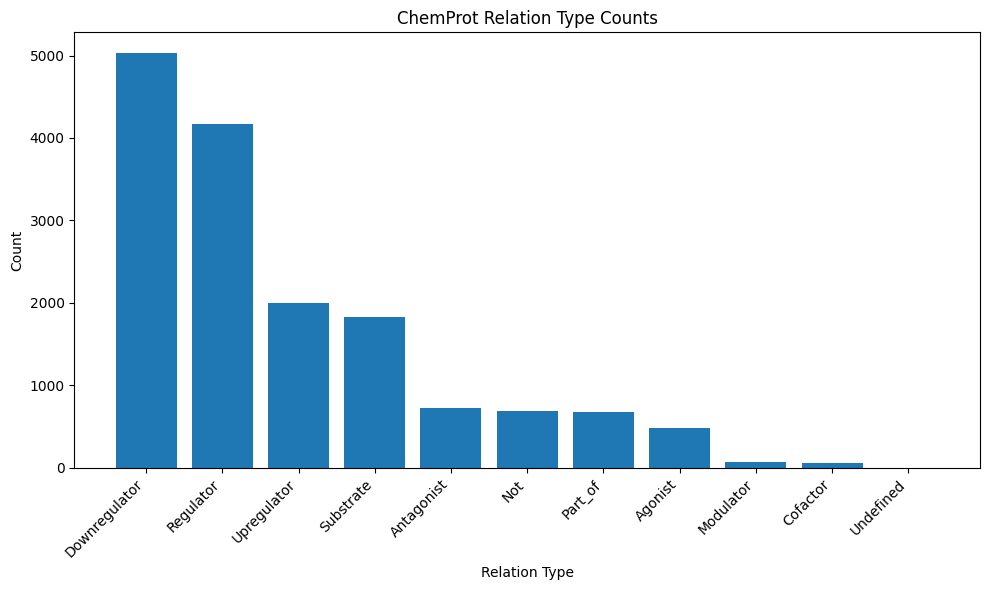

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(relation_counts_df["Relation Type"], relation_counts_df["Count"])
plt.xlabel("Relation Type")
plt.ylabel("Count")
plt.title("ChemProt Relation Type Counts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#Dataset Analysis (ChemProt)

## The Columns in the Dataset

In [ ]:
print("Top-level fields in EU-ADR example:")
print(euadr_data[0].keys())

Top-level fields in EU-ADR example:
dict_keys(['id', 'document_id', 'passages', 'entities', 'events', 'coreferences', 'relations'])


## Type of Entities

In [ ]:
entity_counter = Counter()
for sample in euadr_data:
    for entity in sample.get("entities", []):
        entity_counter[entity["type"]] += 1

entity_counts_df = pd.DataFrame(entity_counter.items(), columns=["Entity Type", "Count"])
entity_counts_df.sort_values(by="Count", ascending=False, inplace=True)

print(entity_counts_df)

                   Entity Type  Count
2                                5782
4  Genes & Molecular Sequences   2875
0         Diseases & Disorders   2496
1            Chemicals & Drugs   1816
3    SNP & Sequence variations    608


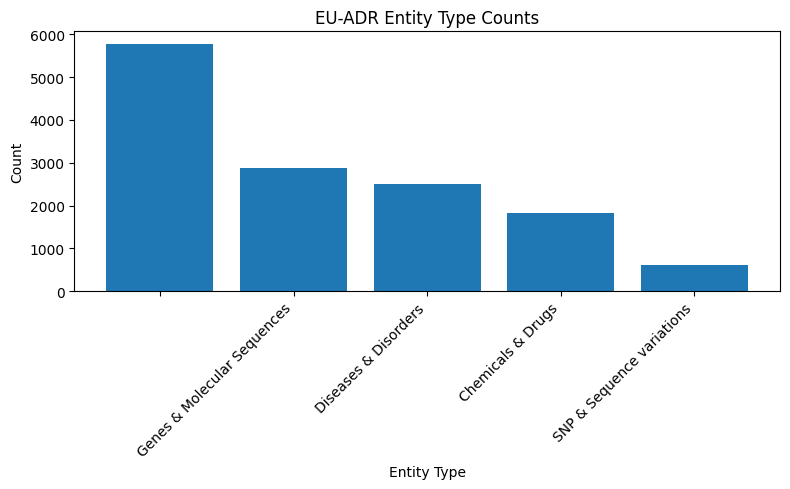

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(entity_counts_df["Entity Type"], entity_counts_df["Count"])
plt.xlabel("Entity Type")
plt.ylabel("Count")
plt.title("EU-ADR Entity Type Counts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Relations in Datasets

In [ ]:
relation_counter = Counter()
for sample in euadr_data:
    for relation in sample.get("relations", []):
        relation_counter[relation["type"]] += 1


relation_counts_df = pd.DataFrame(relation_counter.items(), columns=["Relation Type", "Count"])
relation_counts_df.sort_values(by="Count", ascending=False, inplace=True)

print(relation_counts_df)


  Relation Type  Count
1            PA   2473
0            SA    281
2            NA    137


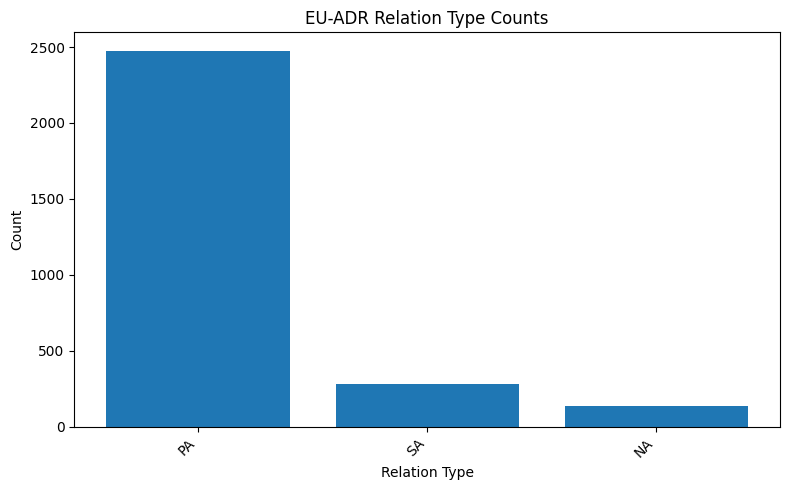

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(relation_counts_df["Relation Type"], relation_counts_df["Count"])
plt.xlabel("Relation Type")
plt.ylabel("Count")
plt.title("EU-ADR Relation Type Counts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Overlapping Terms

In [ ]:
def extract_entity_names(dataset):
    entity_names = set()
    for example in dataset:
        for ent in example.get("entities", []):
            text = ent["text"][0].strip().lower()
            entity_names.add(text)
    return entity_names


chemprot_names = extract_entity_names(all_chemprot)
euadr_names = extract_entity_names(euadr_data)


overlapping_names = chemprot_names.intersection(euadr_names)

In [ ]:
print(f"Overlapping entity names: {len(overlapping_names)}")
print("Sample overlaps:", list(overlapping_names)[:10])

Overlapping entity names: 538
Sample overlaps: ['cyp2d6', 'nlrp3', 'interleukin', 'cyp3a', 'mek', 'mg132', 'phosphatases', 'tlr4', 'amylase', 'caspases']


#Neo4j Visulization

In [ ]:
# --- Neo4j connection ---
uri = "neo4j+s://c7bbe2a5.databases.neo4j.io"
username = "neo4j"
password = "vC8-jCZm7W_XCB9uQ43vWOzdJNM7ixPp5assYPe9E9g"
driver = GraphDatabase.driver(uri, auth=(username, password))


## EU-ADR

In [ ]:
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")

data = euadr_data

create_entity_query = """
MERGE (e:Entity {uid: $uid})
SET e.name = $name, e.type = $type
"""

create_relation_query = """
MATCH (e1:Entity {uid: $id1}), (e2:Entity {uid: $id2})
MERGE (e1)-[r:%s]->(e2)
"""

def insert_shared_node_graph(data):
    with driver.session() as session:
        total_inserted = 0
        total_skipped = 0

        for entry in data:
            entities = entry["entities"]
            relations = entry["relations"]

            id_to_entity = {e["id"]: e for e in entities}

            for e in entities:
                if not e["text"]:
                    continue
                uid = f"{e['text'][0].lower()}_{e['type']}"
                session.run(create_entity_query, {
                    "uid": uid,
                    "name": e["text"][0],
                    "type": e["type"]
                })

            for rel in relations:
                arg1 = id_to_entity.get(rel["arg1_id"])
                arg2 = id_to_entity.get(rel["arg2_id"])
                if not arg1 or not arg2 or not arg1["text"] or not arg2["text"]:
                    total_skipped += 1
                    continue

                uid1 = f"{arg1['text'][0].lower()}_{arg1['type']}"
                uid2 = f"{arg2['text'][0].lower()}_{arg2['type']}"
                rel_type = rel["type"].replace(":", "_")

                session.run(create_relation_query % rel_type, {
                    "id1": uid1,
                    "id2": uid2
                })
                total_inserted += 1

insert_shared_node_graph(data)


<ipython-input-64-c1ca0c9f231c>:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


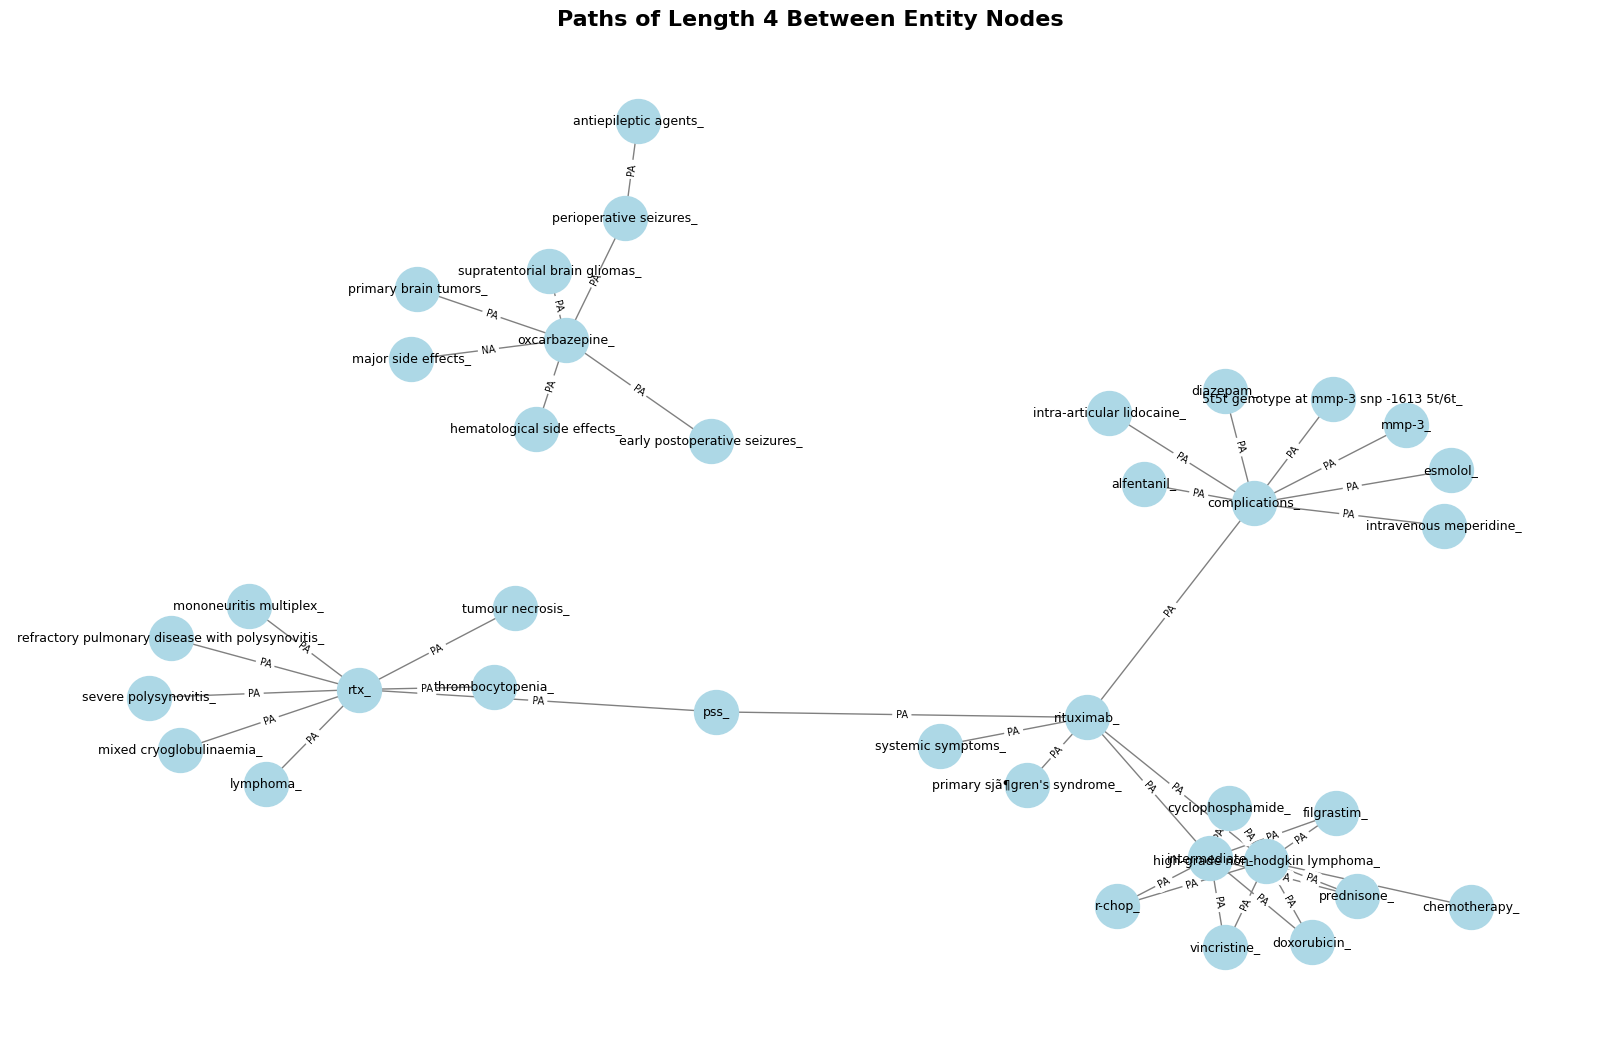

In [ ]:
def get_paths_of_length_4(limit_paths=50):
    import networkx as nx
    G = nx.Graph()

    with driver.session() as session:
        # Query all undirected paths of length exactly 4
        query = """
        MATCH p = (a:Entity)-[*4]-(b:Entity)
        RETURN p
        LIMIT $limit
        """
        results = session.run(query, {"limit": limit_paths})

        for record in results:
            path = record["p"]
            nodes = path.nodes
            rels = path.relationships

            for i in range(len(nodes) - 1):
                node1 = nodes[i]["uid"]
                node2 = nodes[i + 1]["uid"]
                rel_type = rels[i].type
                G.add_edge(node1, node2, label=rel_type)

    return G

G = get_paths_of_length_4(limit_paths=200)

plt.figure(figsize=(16, 10))
pos = nx.spring_layout(G, seed=42, k=0.3)


nx.draw(
    G, pos, with_labels=True, node_color="lightblue", edge_color="gray",
    node_size=1000, font_size=9, linewidths=1
)


edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)


plt.title("Paths of Length 4 Between Entity Nodes", fontsize=16, fontweight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()



## ChemProt

In [ ]:

with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")


chemprot_ds = load_dataset("bigbio/chemprot", "chemprot_bigbio_kb")
data = chemprot_ds["train"]


create_entity_query = """
MERGE (e:Entity {uid: $uid})
SET e.name = $name, e.type = $type
"""

create_relation_query = """
MATCH (e1:Entity {uid: $id1}), (e2:Entity {uid: $id2})
MERGE (e1)-[r:%s]->(e2)
"""


def insert_chemprot_graph(data):
    with driver.session() as session:
        inserted = 0
        skipped = 0

        for entry in data:
            id_to_entity = {e["id"]: e for e in entry["entities"]}


            for e in entry["entities"]:
                if not e["text"]:
                    continue
                uid = f"{e['text'][0].lower()}_{e['type']}"
                session.run(create_entity_query, {
                    "uid": uid,
                    "name": e["text"][0],
                    "type": e["type"]
                })


            for rel in entry["relations"]:
                arg1 = id_to_entity.get(rel["arg1_id"])
                arg2 = id_to_entity.get(rel["arg2_id"])

                if not arg1 or not arg2 or not arg1["text"] or not arg2["text"]:
                    skipped += 1
                    continue

                uid1 = f"{arg1['text'][0].lower()}_{arg1['type']}"
                uid2 = f"{arg2['text'][0].lower()}_{arg2['type']}"
                rel_type = rel["type"].replace(":", "_")

                session.run(create_relation_query % rel_type, {
                    "id1": uid1,
                    "id2": uid2
                })
                inserted += 1



insert_chemprot_graph(data)

🧹 Graph wiped — ready for ChemProt ingest.


<ipython-input-69-69359d7d64ba>:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


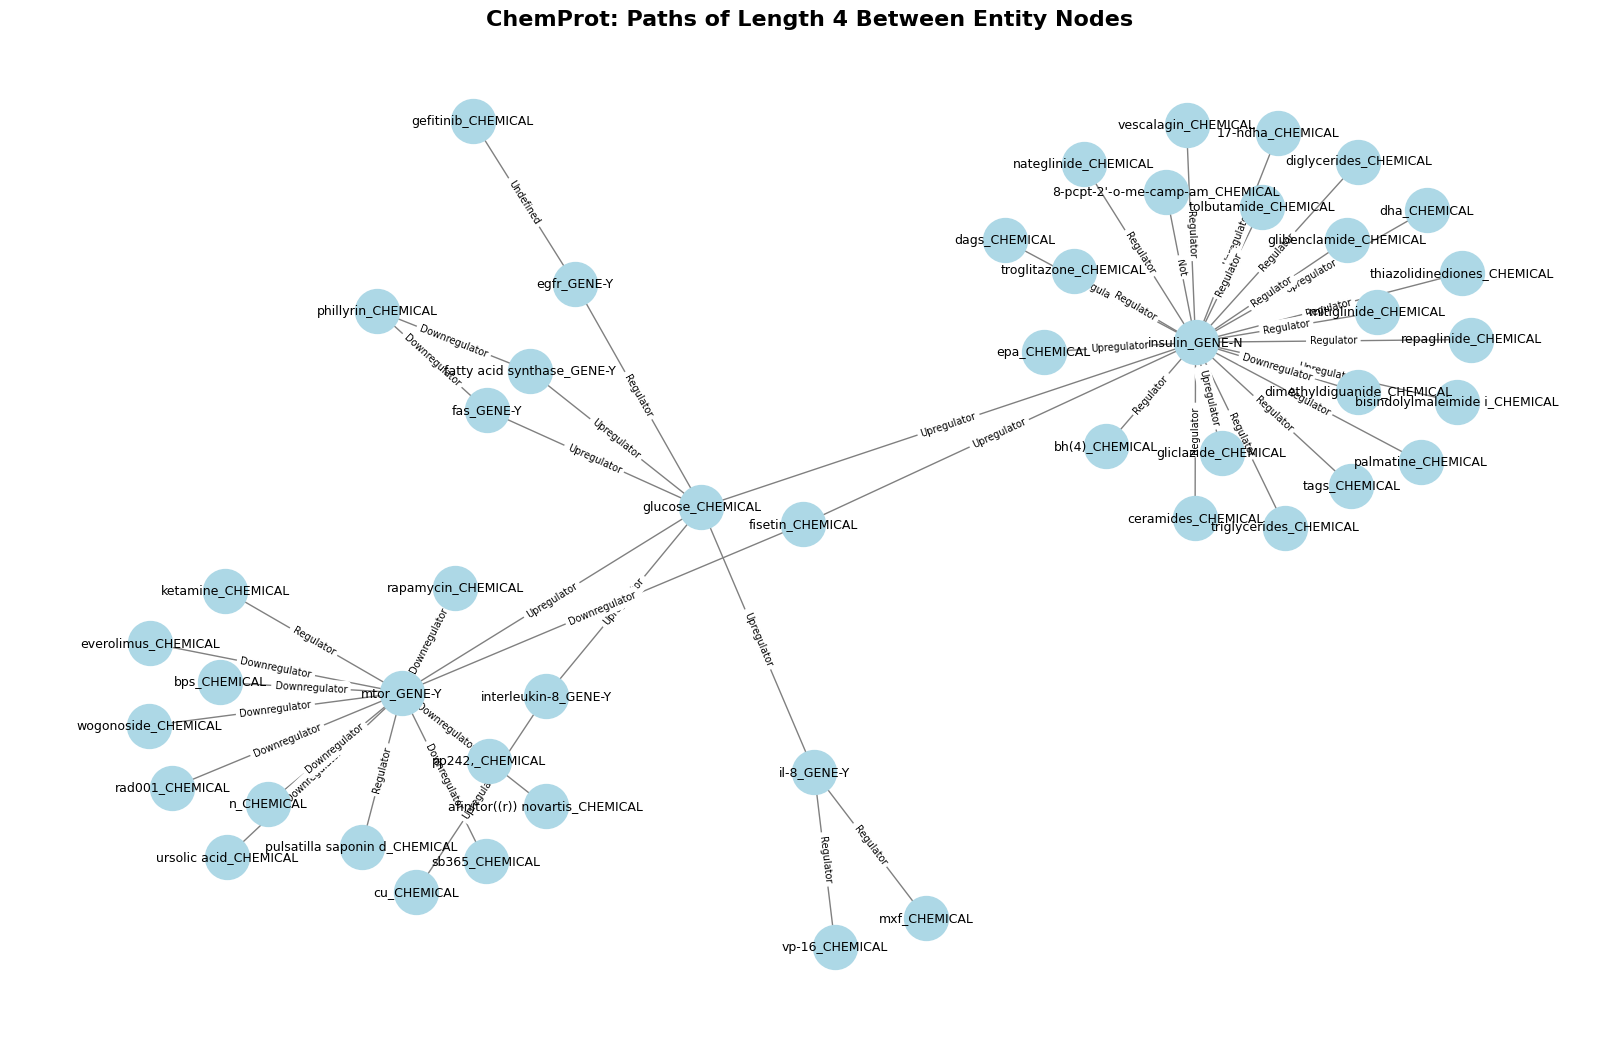

In [ ]:
def get_chemprot_paths_of_length_4(limit_paths=200):
    import networkx as nx
    G = nx.Graph()

    with driver.session() as session:
        # Cypher query to get length-4 paths in ChemProt graph
        query = """
        MATCH p = (a:Entity)-[*4]-(b:Entity)
        RETURN p
        LIMIT $limit
        """
        results = session.run(query, {"limit": limit_paths})

        for record in results:
            path = record["p"]
            nodes = path.nodes
            rels = path.relationships

            for i in range(len(nodes) - 1):
                node1 = nodes[i]["uid"]
                node2 = nodes[i + 1]["uid"]
                rel_type = rels[i].type
                G.add_edge(node1, node2, label=rel_type)

    return G

# Load ChemProt path graph
G = get_chemprot_paths_of_length_4(limit_paths=50)

# Draw the graph
plt.figure(figsize=(16, 10))
pos = nx.spring_layout(G, seed=42, k=0.3)

nx.draw(
    G, pos, with_labels=True, node_color="lightblue", edge_color="gray",
    node_size=1000, font_size=9, linewidths=1
)

# Add edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.title("ChemProt: Paths of Length 4 Between Entity Nodes", fontsize=16, fontweight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()


#Exporting Data

## Download to Google Collab FIle

In [ ]:
with open("/content/euadr_full.json", "w") as f:
    json.dump(euadr.to_list(), f, indent=2)

with open("/content/chemprot_train.json", "w") as f:
    json.dump(train_list, f, indent=2)

with open("/content/chemprot_validation.json", "w") as f:
    json.dump(val_list, f, indent=2)

with open("/content/chemprot_test.json", "w") as f:
    json.dump(test_list, f, indent=2)

## Download to Local Files

In [ ]:
files.download("/content/euadur_full.json")
files.download("/content/chemprot_train.json")
files.download("/content/chemprot_validation.json")
files.download("/content/chemprot_test.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>